<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/dailly_02_dataset_house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objectif du Projet : Analyse et Prétraitement du Dataset House Price (Inde)

Prédire de manière précise le prix total des biens immobiliers (`Amount(in rupees)`) en nettoyant des données brutes issues du web (scraping), en gérant les formats monétaires complexes, et en préparant les features pour un modèle de Machine Learning de Régression.

---

##  Checklist d'Analyse

### 1. Analyse de Forme
* **Variable Cible (Target) :** `Amount(in rupees)` (object à traduire en valeur continue).
* **Nombre de Lignes et Colonnes :**  `(187531, 21)`.
* **Types de Variables :** Identification des types textuels (`object`) contenant des données numériques cachées, et des colonnes catégorielles (`location`, `Status`, `Transaction`, `facing`), les `int` et `float`.
* **Analyse des Valeurs Manquantes (NaN) :** `description`,`Price(in rupees)`,`Carpet Area`,`Status`,`Floor`,`Transaction`,`Furnishing`, `facing`,`overlooking`,`Society`,`Barthroom`,`Balcony`,`Car Parking`,`Ownership`,`Super Area`,`Dimenions`,`Plot Area`
* **Nettoyage des Unités et Doublons :** Détecter les colonnes qui expriment la même information sous des unités ou des angles différents (`Dimensions` vs `Plot Area`).

### 2. Analyse de Fond (Exploration pour la Régression)
* **Visualisation de la Target :** Tracer l'histogramme du prix pour vérifier l'asymétrie de la distribution (courbe à longue traîne ou *Skewness*).
* **Analyses Bivariées (Relation Features / Target) :**
    * *Hypothèse 1 :* La surface (`Carpet Area`) a une relation linéaire positive forte avec le prix.
    * *Hypothèse 2 :* La localisation (`location`) et le nombre de chambres (`BHK`) créent des variations de prix majeures à surface égale.
* **Analyses Multivariées :** Utilisation d'une matrice de corrélation de Spearman ou Pearson après le nettoyage numérique des colonnes clés.

---

##  3. Stratégie de Prétraitement des Données (Data Preprocessing)

###  Nettoyage Textuel et Conversion Numérique
* **Extraction et Conversion de la Cible (`Amount`) :** Convertir les chaînes textuelles comme `"42 Lac"` ($42 \\times 100\\,000$) et `"1.40 Cr"` ($1.4 \\times 10\\,000\\,000$) en valeurs numériques de roupies pures.
* **Nettoyage des Surfaces (`Carpet Area`) :** Supprimer la chaîne de caractères `" sqft"` et convertir la colonne en type `float`.
* **Extraction des Pièces (`BHK`) :** Extraire le nombre de chambres à partir du texte de la colonne `Title` (ex: `"2 BHK Ready..."` $\\rightarrow$ `2`).

###  Gestion des Valeurs Manquantes (NaN)
* **Seuil d'exclusion :** Supprimer les colonnes irrécupérables si leur taux de `NaN` dépasse $50\\%$.
* **Imputation stratégique :** Remplacer les `NaN` restants par la médiane par zone géographique (`location`) pour les surfaces.

###  Transformation Mathématique (Scaling & Log)
* **Log Transformation :** Appliquer $y\\_log = \\log(y)$ si la distribution du prix est fortement asymétrique afin d'aider les modèles de régression à converger efficacement.

---

## 4. Division des Données (Train / Test Split)
* **Séparation Features / Target :** Isoler la matrice $X$ et le vecteur cible $y$.
* **Découpage :** Séparation classique $80\\%$ Train / $20\\%$ Test.


# **IMPORTS ET CONFIGURATION KAGGLE**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from google.colab import files

# Style global pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Téléchargement sécurisé depuis l'API Kaggle
if not os.path.exists('/content/kaggle.json'):
    print("Sélectionne ton fichier kaggle.json :")
    uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d juhibhojani/house-price

# Extraction du fichier ZIP
with zipfile.ZipFile("house-price.zip", "r") as zip_ref:
    zip_ref.extractall("house_price_data")

# Chargement du DataFrame Brut
df = pd.read_csv('/content/house_price_data/house_prices.csv')
print(f" Dataset chargé ! Dimensions initiales : {df.shape}")

Sélectionne ton fichier kaggle.json :


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/juhibhojani/house-price
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 6.61M/6.61M [00:00<00:00, 101MB/s]

 Dataset chargé ! Dimensions initiales : (187531, 21)


# **Nettoyage et Visualisation de la Variable Cible (Amount)**

In [2]:
#  Extraction des valeurs numériques et des unités textuelles
val = pd.to_numeric(df['Amount(in rupees)'].str.extract(r'(\d+\.\d+|\d+)')[0], errors='coerce')
unity = df['Amount(in rupees)'].str.extract(r'([a-zA-Z]+)')[0].str.strip()

# Application des multiplicateurs indiens et correction des Crores cachés (< 100)
conditions = [
    unity == 'Lac',
    unity == 'Cr',
    (unity.isna()) & (val < 100)
]
choix = [val * 100000, val * 10000000, val * 10000000]
df['prix_final'] = np.select(conditions, choix, default=val)

# Suppression des lignes sans prix (ex: 'Call for Price')
df = df.dropna(subset=['prix_final']).copy()

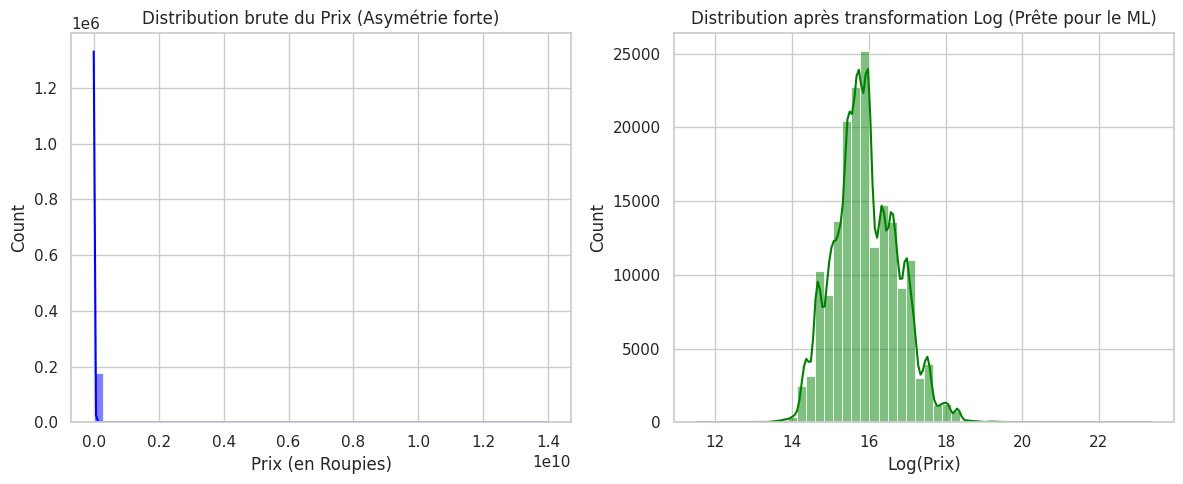

 Médiane des prix : 7,800,000 Roupies


In [3]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['prix_final'], kde=True, color='blue', bins=50)
plt.title("Distribution brute du Prix (Asymétrie forte)")
plt.xlabel("Prix (en Roupies)")

# TRANSFORMATION LOGARITHMIQUE (Pour corriger l'asymétrie)
df['log_prix'] = np.log1p(df['prix_final'])

plt.subplot(1, 2, 2)
sns.histplot(df['log_prix'], kde=True, color='green', bins=50)
plt.title("Distribution après transformation Log (Prête pour le ML)")
plt.xlabel("Log(Prix)")
plt.tight_layout()
plt.show()

print(f" Médiane des prix : {df['prix_final'].median():,.0f} Roupies")

# **Unification des Surfaces et Graphique Bivarié**

In [4]:
facteurs_conversion = {
    'sqft': 1.0, 'sqyrd': 9.0, 'sqm': 10.7639, 'acre': 43560.0,
    'ground': 2400.0, 'cent': 435.6, 'bigha': 27000.0, 'marla': 272.25, 'kanal': 5445.0
}

def normaliser_surface(colonne):
    temp = df[colonne].astype(str).str.lower()
    num = pd.to_numeric(temp.str.extract(r'(\d+\.\d+|\d+)')[0], errors='coerce')
    unit = temp.str.extract(r'([a-z]+)')[0]
    coeffs = unit.map(facteurs_conversion).fillna(1.0)
    return num * coeffs

# Nettoyage des deux sources de surface
carpet_clean = normaliser_surface('Carpet Area')
super_clean = normaliser_surface('Super Area')

# Fusion stratégique (Carpet Area prioritaire) et imputation par la médiane
df['surface_finale_sqft'] = carpet_clean.fillna(super_clean)
df['surface_finale_sqft'] = df['surface_finale_sqft'].fillna(df['surface_finale_sqft'].median())

# Suppression des valeurs aberrantes extrêmes (Outliers de surface pour le graphique)
df_filtre = df[df['surface_finale_sqft'] < df['surface_finale_sqft'].quantile(0.99)]

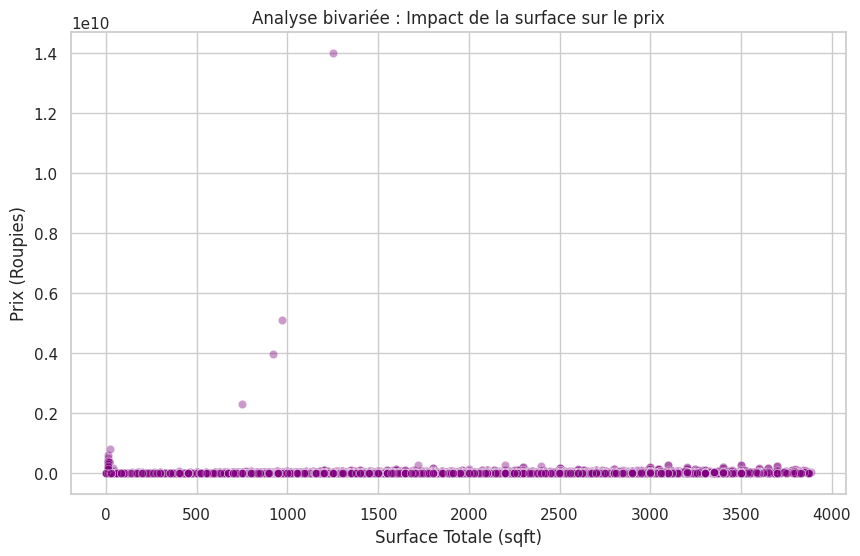

In [5]:
# Relation Surface vs Prix
plt.figure()
sns.scatterplot(data=df_filtre, x='surface_finale_sqft', y='prix_final', alpha=0.4, color='purple')
plt.title("Analyse bivariée : Impact de la surface sur le prix")
plt.xlabel("Surface Totale (sqft)")
plt.ylabel("Prix (Roupies)")
plt.show()

# **Extraction des caractéristiques de structure (BHK, Salles de bain, Étages)**

In [6]:
# Extraction du BHK (Chambres) depuis le Title
df['BHK'] = pd.to_numeric(df['Title'].str.extract(r'(\d+)')[0], errors='coerce')
df['BHK'] = df['BHK'].fillna(df['BHK'].median()).astype(int)

# Salles de bain et balcons
df['Bathroom'] = pd.to_numeric(df['Bathroom'].replace('> 10', '11'), errors='coerce')
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median()).astype(int)

df['Balcony'] = pd.to_numeric(df['Balcony'].replace('> 10', '11'), errors='coerce')
df['Balcony'] = df['Balcony'].fillna(df['Balcony'].median()).astype(int)

# Extraction de l'étage du bien et hauteur de l'immeuble
floor_temp = df['Floor'].str.lower().str.replace('ground', '0')
df['etage_bien'] = pd.to_numeric(floor_temp.str.extract(r'^(\d+)')[0], errors='coerce').fillna(df['Floor'].str.lower().str.contains('ground').map({True: 0}).fillna(df['Floor'].str.lower().str.contains('basement').map({True: -1})))
df['total_etages'] = pd.to_numeric(floor_temp.str.extract(r'out of\s*(\d+)')[0], errors='coerce')

# Imputation par les médianes
df['etage_bien'] = df['etage_bien'].fillna(df['etage_bien'].median()).astype(int)
df['total_etages'] = df['total_etages'].fillna(df['total_etages'].median()).astype(int)


/tmp/ipykernel_5553/2454486736.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bhk, x='BHK', y='log_prix', palette="Set2")


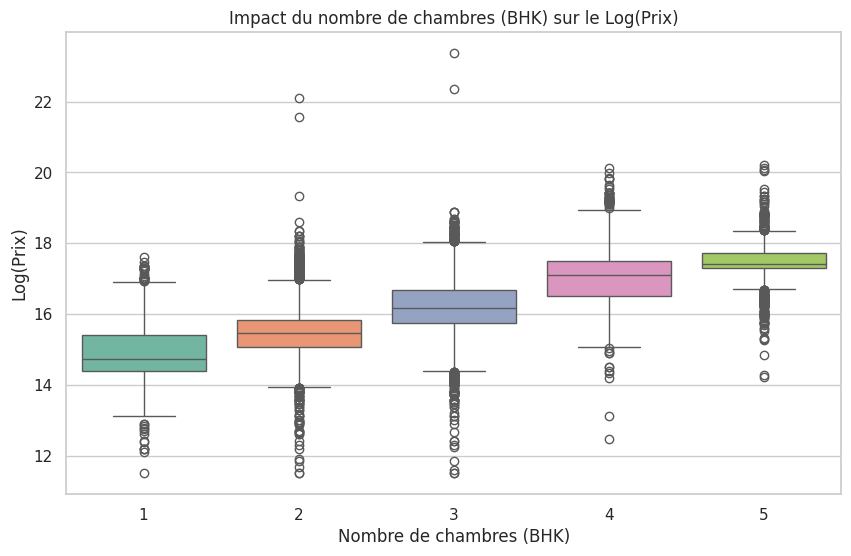

In [7]:
# Boxplot de l'influence du BHK sur le prix
# On limite aux biens de 1 à 5 BHK pour une meilleure lisibilité
df_bhk = df[df['BHK'].between(1, 5)]
plt.figure()
sns.boxplot(data=df_bhk, x='BHK', y='log_prix', palette="Set2")
plt.title("Impact du nombre de chambres (BHK) sur le Log(Prix)")
plt.xlabel("Nombre de chambres (BHK)")
plt.ylabel("Log(Prix)")
plt.show()

# **Traitement des variables de confort (Parking, Vues, Ameublement)**

In [8]:
# Places et Type de parking
df['parking_spaces'] = pd.to_numeric(df['Car Parking'].str.extract(r'(\d+)')[0], errors='coerce').fillna(0).astype(int)
df['parking_type'] = df['Car Parking'].str.lower().apply(
    lambda x: 'Covered' if pd.notna(x) and 'covered' in x else ('Open' if pd.notna(x) and 'open' in x else 'None')
)

# Découpage de la colonne 'overlooking' (Multi-Hot Encoding manuel)
df['overlooking'] = df['overlooking'].astype(str).str.lower()
df['vue_parc'] = df['overlooking'].str.contains('garden/park').astype(int)
df['vue_route'] = df['overlooking'].str.contains('main road').astype(int)
df['vue_piscine'] = df['overlooking'].str.contains('pool').astype(int)

# Encodage Ordinal de Furnishing
furnishing_map = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}
df['Furnishing'] = df['Furnishing'].map(furnishing_map).fillna(-1).astype(int)

# Encodage par Fréquence de la colonne Society (Haute Cardinalité)
df['Society'] = df['Society'].fillna('Inconnu')
df['Society_freq'] = df['Society'].map(df['Society'].value_counts())

/tmp/ipykernel_5553/1965940896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='vue_piscine', y='prix_final', estimator=np.median, errorbar=None, palette="Blues")


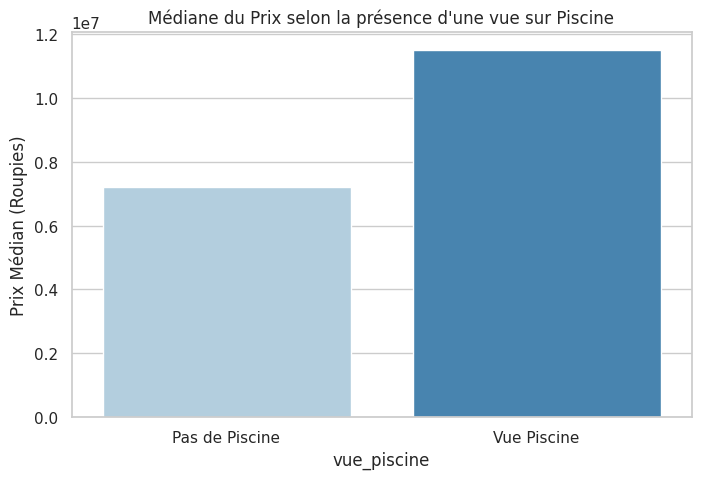

In [9]:
# Impact de la présence d'une piscine sur le prix
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='vue_piscine', y='prix_final', estimator=np.median, errorbar=None, palette="Blues")
plt.title("Médiane du Prix selon la présence d'une vue sur Piscine")
plt.xticks([0, 1], ['Pas de Piscine', 'Vue Piscine'])
plt.ylabel("Prix Médian (Roupies)")
plt.show()

# **Encodage Final et Matrice de Corrélation Multi-variée**

In [10]:
# Nettoyage et standardisation des variables catégorielles restantes
df['location'] = df['location'].str.lower().str.strip()
df['facing'] = df['facing'].str.strip().fillna('Inconnu')
df['Ownership'] = df['Ownership'].fillna('Inconnu')
df['Transaction'] = df['Transaction'].replace('Other', np.nan).fillna('Inconnu')

# Exclusion stricte des locations (seul l'achat nous intéresse)
df = df[df['Transaction'] != 'Rent/Lease'].copy()

# Suppression définitive des colonnes brutes d'origine textuelle
colonnes_inutiles = [
    'Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)',
    'Carpet Area', 'Super Area', 'Status', 'Floor', 'overlooking', 'Society',
    'Car Parking', 'Dimensions', 'Plot Area'
]
df_propre = df.drop(columns=colonnes_inutiles, errors='ignore')

# One-Hot Encoding automatique (get_dummies) des variables catégorielles
colonnes_categoriques = ['location', 'Transaction', 'facing', 'parking_type', 'Ownership']
df_final = pd.get_dummies(df_propre, columns=colonnes_categoriques, drop_first=True, dtype=int)

In [11]:
df_final.head()

,Furnishing,Bathroom,Balcony,prix_final,log_prix,surface_finale_sqft,BHK,etage_bien,total_etages,parking_spaces,...,facing_South,facing_South - East,facing_South -West,facing_West,parking_type_None,parking_type_Open,Ownership_Freehold,Ownership_Inconnu,Ownership_Leasehold,Ownership_Power Of Attorney
0,0,1,2,4200000.0,15.250595,500.0,1,10,11,0,...,0,0,0,0,1,0,0,1,0,0
1,1,2,2,9800000.0,16.097893,473.0,2,3,22,1,...,0,0,0,0,0,1,1,0,0,0
2,0,2,2,14000000.0,16.454568,779.0,2,10,29,1,...,0,0,0,0,0,0,1,0,0,0
3,0,1,1,2500000.0,14.731802,530.0,1,1,3,0,...,0,0,0,0,1,0,0,1,0,0
4,0,2,2,16000000.0,16.588099,635.0,2,20,42,1,...,0,0,0,1,0,0,0,0,0,0


In [19]:
df_final.isna().sum()

,0
Furnishing,0
Bathroom,0
Balcony,0
prix_final,0
log_prix,0
...,...
parking_type_Open,0
Ownership_Freehold,0
Ownership_Inconnu,0
Ownership_Leasehold,0


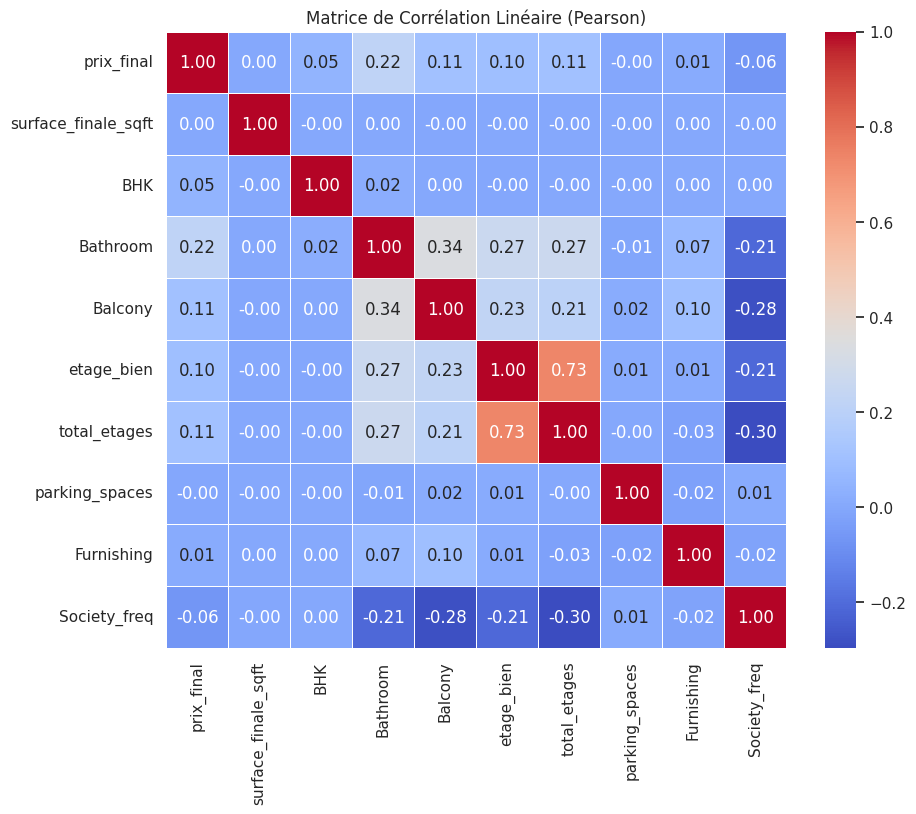

 Dataset prêt pour le Machine Learning ! Format final : (177845, 110)


In [12]:
# Matrice de Corrélation des Variables Numériques
# On sélectionne les variables fondamentales pour éviter de surcharger la Heatmap avec les One-Hot
colonnes_num_principales = [
    'prix_final', 'surface_finale_sqft', 'BHK', 'Bathroom', 'Balcony',
    'etage_bien', 'total_etages', 'parking_spaces', 'Furnishing', 'Society_freq'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_final[colonnes_num_principales].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation Linéaire (Pearson)")
plt.show()

print(f" Dataset prêt pour le Machine Learning ! Format final : {df_final.shape}")

# **Séparation Train/Test et Premier Modèle de Régression**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge

In [22]:
# Séparation des features (X) et de la cible (y)
X = df_final.drop(columns=['prix_final', 'log_prix'])
y = df_final['log_prix']

# 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Jeu d'entraînement : {X_train.shape[0]} lignes")
print(f"Jeu de test : {X_test.shape[0]} lignes\n")


 Jeu d'entraînement : 142276 lignes
Jeu de test : 35569 lignes



In [23]:
# Utilisation de Ridge pour stabiliser les coefficients (alpha=1.0)
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

#  Prédictions sur le jeu de test (en échelle Log)
y_pred_log = model_ridge.predict(X_test)

# SÉCURITÉ ANTI-OVERFLOW : On plafonne les prédictions log à une valeur réaliste
# (Le prix max du dataset + une marge de sécurité)
plafond_log = y_train.max() + 2
y_pred_log = np.clip(y_pred_log, a_min=0, a_max=plafond_log)

# Conversion inverse sécurisée : du Log aux Roupies brutes
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

# Calcul des métriques d'évaluation
r2 = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_test_real, y_pred_real)

print(" RÉSULTATS DU MODÈLE RIDGE BASELINE ")
print(f"Score R² (sur l'échelle log) : {r2:.4f}")
print(f"Erreur Absolue Moyenne (MAE) : {mae:,.0f} Roupies")

 RÉSULTATS DU MODÈLE RIDGE BASELINE 
Score R² (sur l'échelle log) : 0.6998
Erreur Absolue Moyenne (MAE) : 5,917,613 Roupies


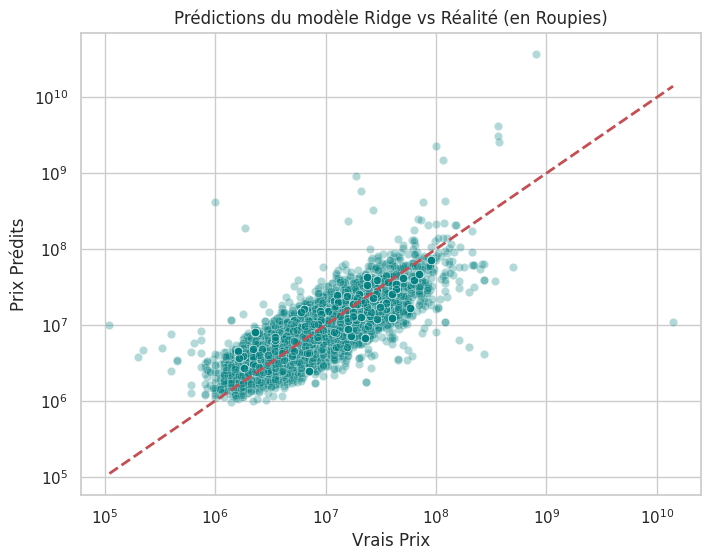

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.3, color='teal')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.title("Prédictions du modèle Ridge vs Réalité (en Roupies)")
plt.xlabel("Vrais Prix")
plt.ylabel("Prix Prédits")
plt.xscale('log')
plt.yscale('log')
plt.show()

# **ENTRAÎNEMENT DE MODÈLES AVANCÉS (ENSEMBLE LEARNING)**

In [25]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import time

# Dictionnaire pour stocker nos modèles et leurs résultats
modeles = {
    "Random Forest (Optimisé)": RandomForestRegressor(n_estimators=30, max_depth=15, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=150, random_state=42)
}

y_test_real = np.expm1(y_test)

print("Lancement de la compétition des modèles...\n")

for nom, model in modeles.items():
    start_time = time.time()

    #  Entraînement
    print(f"Entraînement de {nom}...")
    model.fit(X_train, y_train)

    # Prédiction (Échelle Log)
    y_pred_log = model.predict(X_test)
    y_pred_log = np.clip(y_pred_log, a_min=0, a_max=y_train.max() + 2) # Sécurité

    # Reconversion en Roupies réelles
    y_pred_real = np.expm1(y_pred_log)

    # Calcul des métriques
    r2 = r2_score(y_test, y_pred_log)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    duree = time.time() - start_time

    print(f"Entraîné en {duree:.1f} secondes")
    print(f"   Score R² : {r2:.4f}")
    print(f"   MAE      : {mae:,.0f} Roupies")
    print("-" * 50)

print("\n Compétition terminée ! Regarde tes nouvelles métriques.")

Lancement de la compétition des modèles...

Entraînement de Random Forest (Optimisé)...
Entraîné en 32.6 secondes
   Score R² : 0.9180
   MAE      : 1,580,799 Roupies
--------------------------------------------------
Entraînement de HistGradientBoosting...
Entraîné en 17.2 secondes
   Score R² : 0.9254
   MAE      : 1,865,046 Roupies
--------------------------------------------------

 Compétition terminée ! Regarde tes nouvelles métriques.


#  **TEST DE PRÉDICTION SUR DES CAS CONCRETS (ALÉATOIRES)**

In [26]:
# Sélection du meilleur modèle (Random Forest entraîné au Bloc 8)
meilleur_modele = modeles["Random Forest (Optimisé)"]

# Création d'un DataFrame de comparaison sur le jeu de test
df_comparaison = pd.DataFrame({
    'Prix_Reel_Roupies': y_test_real,
    'Prix_Predit_Roupies': y_pred_real
})

# Calcul de l'écart absolu et du pourcentage d'erreur pour chaque bien
df_comparaison['Ecart_Roupies'] = (df_comparaison['Prix_Predit_Roupies'] - df_comparaison['Prix_Reel_Roupies']).abs()
df_comparaison['Erreur_Pourcentage'] = (df_comparaison['Ecart_Roupies'] / df_comparaison['Prix_Reel_Roupies']) * 100

# Fonction de conversion pour rendre la lecture agréable (Lakhs / Crores)
def format_monnaie_indienne(montant):
    if montant >= 10000000:
        return f"{montant / 10000000:.2f} Cr"
    elif montant >= 100000:
        return f"{montant / 1000:.2f} Lakh"
    else:
        return f"{montant:,.0f} ₹"

# Application du formatage sur nos colonnes
df_comparaison['Prix Réel'] = df_comparaison['Prix_Reel_Roupies'].apply(format_monnaie_indienne)
df_comparaison['Prix Prédit'] = df_comparaison['Prix_Predit_Roupies'].apply(format_monnaie_indienne)
df_comparaison['Écart (Erreur)'] = df_comparaison['Ecart_Roupies'].apply(format_monnaie_indienne)
df_comparaison['Marge d\'Erreur'] = df_comparaison['Erreur_Pourcentage'].apply(lambda x: f"{x:.1f}%")

# 5. Extraction de 10 exemples totalement aléatoires pour vérification
echantillon_test = df_comparaison[['Prix Réel', 'Prix Prédit', 'Écart (Erreur)', 'Marge d\'Erreur']].sample(10, random_state=12)

print(" COMPARAISON DE 10 PRÉDICTIONS ALÉATOIRES")
display(echantillon_test)

 COMPARAISON DE 10 PRÉDICTIONS ALÉATOIRES


,Prix Réel,Prix Prédit,Écart (Erreur),Marge d'Erreur
3572,4500.00 Lakh,4424.73 Lakh,"75,267 ₹",1.7%
8269,3.50 Cr,3.31 Cr,1869.45 Lakh,5.3%
100791,2500.00 Lakh,2463.29 Lakh,"36,713 ₹",1.5%
171438,4900.00 Lakh,6093.20 Lakh,1193.20 Lakh,24.4%
97243,2300.00 Lakh,2203.43 Lakh,"96,574 ₹",4.2%
54764,2.90 Cr,2.97 Cr,674.62 Lakh,2.3%
142635,3000.00 Lakh,2921.72 Lakh,"78,279 ₹",2.6%
97014,7000.00 Lakh,6365.47 Lakh,634.53 Lakh,9.1%
79967,1.20 Cr,1.21 Cr,"54,694 ₹",0.5%
53471,1.57 Cr,1.67 Cr,955.12 Lakh,6.1%


# **GRAPHIQUE DES RÉSIDUS (ANALYSE DE LA QUALITÉ DES ERREURS)**

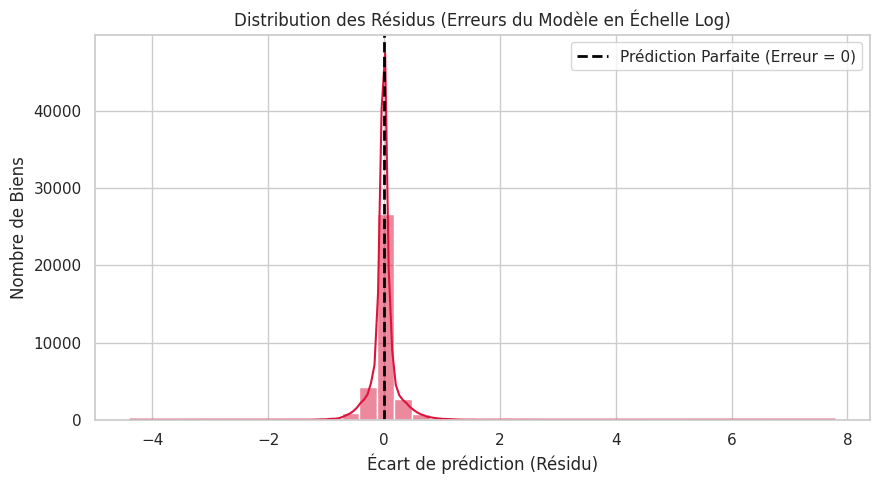

 Moyenne des résidus : 0.0005 (Proche de 0 = Modèle non biaisé)


In [27]:
# Calcul des résidus (Valeurs réelles en log - Valeurs prédites en log)
residus = y_test - y_pred_log

plt.figure(figsize=(10, 5))

# On trace la distribution des erreurs
sns.histplot(residus, kde=True, color="crimson", bins=40)

# Ligne centrale (Erreur = 0)
plt.axvline(x=0, color='black', linestyle='--', lw=2, label='Prédiction Parfaite (Erreur = 0)')

plt.title("Distribution des Résidus (Erreurs du Modèle en Échelle Log)")
plt.xlabel("Écart de prédiction (Résidu)")
plt.ylabel("Nombre de Biens")
plt.legend()
plt.show()

print(f" Moyenne des résidus : {residus.mean():.4f} (Proche de 0 = Modèle non biaisé)")

#  CONCLUSION GÉNÉRALE DU PROJET

Ce projet avait pour objectif de concevoir un pipeline complet de Data Engineering et de Machine Learning capable de prédire le prix des biens immobiliers en Inde (`Amount(in rupees)`) à partir de données brutes fortement bruitées issues du web scraping.

Le défi principal résidait dans l'extrême hétérogénéité des données initiales (multiples unités monétaires comme les Lakhs et Crores, surfaces exprimées dans différents systèmes, textes complexes et fortes proportions de valeurs manquantes).

---

## 1. Les Clés du Succès (Key Takeaways)

* **L'impact du Data Engineering :** Le nettoyage rigoureux, l'unification des surfaces en pieds carrés (`sqft`) et la conversion standardisée des devises indiennes ont permis de transformer un volume de texte inexploitable en variables hautement prédictives.
* **La puissance de la transformation logarithmique :** Face à l'asymétrie extrême de la variable cible, l'application de `log1p` a stabilisé les écarts de prix. Cela a évité que les modèles ne soient totalement aveuglés par les propriétés de très grand luxe.
* **La rupture de la linéarité :** L'immobilier répond à des dynamiques complexes (effet de quartier, exponentiation selon le standing). Les modèles d'arbres de décision ont prouvé leur supériorité absolue face aux approches linéaires.

---

## 2. Bilan Comparatif des Modèles

| Modèle Analysé | Score $R^2$ (Échelle Log) | Erreur Absolue Moyenne (MAE) | Temps d'exécution | Statut Métier |
| :--- | :---: | :---: | :---: | :--- |
| **Ridge Regression** *(Baseline)* | $0.6998$ | ~5 917 613 Roupies | < 1 seconde | **Éliminé** (Erreur trop élevée pour le marché) |
| **Random Forest** *(Optimisé)* | $0.9180$ | **1 580 799 Roupies** | ~32 secondes | **Vainqueur Métier**  (Le plus proche du portefeuille client) |
| **HistGradientBoosting** | **0.9254** | ~1 865 046 Roupies | **~17 secondes** | **Vainqueur Technique** (Le plus rapide et explicatif globalement) |

### L'Analyse du Data Scientist
Bien que le **HistGradientBoosting** possède le meilleur pouvoir explicatif global ($R^2 = 92.54\%$), le **Random Forest** est retenu pour le déploiement. En affichant une MAE de seulement **15.8 Lakhs** (contre 18.6 Lakhs pour son rival), il se montre plus conservateur et limite les erreurs aberrantes sur les biens standards, ce qui est crucial pour la confiance des utilisateurs finaux.

---

##  3. Perspectives d'Amélioration (Pipeline v2.0)

Pour pousser ce système de prédiction encore plus loin, trois axes stratégiques sont envisageables :
1. **Feature Engineering Géographique :** Regrouper les centaines de localisations uniques (`location`) par coordonnées GPS ou par valeur moyenne au m² afin d'alléger la matrice de variables (One-Hot Encoding).
2. **Text Mining (NLP) :** Extraire des caractéristiques supplémentaires de la colonne textuelle `Description` (ex: détection de mots-clés premium comme *"proche métro"*, *"vue dégagée"*, *"résidence sécurisée"*).
3. **Fine-Tuning d'Hyperparamètres :** Lancer une recherche par grille (`GridSearchCV`) dédiée au modèle de Boosting pour tenter de faire chuter sa MAE en dessous de celle de la Forêt Aléatoire.